In [1]:
import gfapy
import networkx as nx
import numpy as np
from itertools import product
from dimod import BQM
from dwave.system import LeapHybridSampler
from dimod.reference.samplers import SimulatedAnnealingSampler
from math import floor
import re

In [2]:
def invert_orient(orient: str):
    if orient == '+':
        return '-'
    elif orient == '-':
        return '+'
    else:
        raise Exception('Bad orient')

In [3]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into the dual graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        forward_node = f'{v1.name}{v1.orient}_{v2.name}{v2.orient}'
        graph.add_node(forward_node, weight=edge_line.EC)
        backward_node = f'{v2.name}{invert_orient(v2.orient)}_{v1.name}{invert_orient(v1.orient)}'
        graph.add_node(backward_node, weight=edge_line.EC)
        for node in graph.nodes:
            node_matches = re.search(
                r'(.+[\+\-])_(.+[\+\-])',
                node
            )
            node_start = node_matches.group(1)
            node_end = node_matches.group(2)
            if node_start == f'{v2.name}{v2.orient}':
                graph.add_edges_from([(forward_node, node)])
            if node_start == f'{v1.name}{invert_orient(v1.orient)}':
                graph.add_edges_from([(backward_node, node)])
            if node_end == f'{v1.name}{v1.orient}':
                graph.add_edges_from([(node, forward_node)])
            if node_end == f'{v2.name}{invert_orient(v2.orient)}':
                graph.add_edges_from([(node, backward_node)])
                
    return graph

In [4]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [5]:
# g = oriented_graph_from_file('../../data/test.gfa')
g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k101.utg.final.gfa')
g = normalise_node_weights(g, 100)

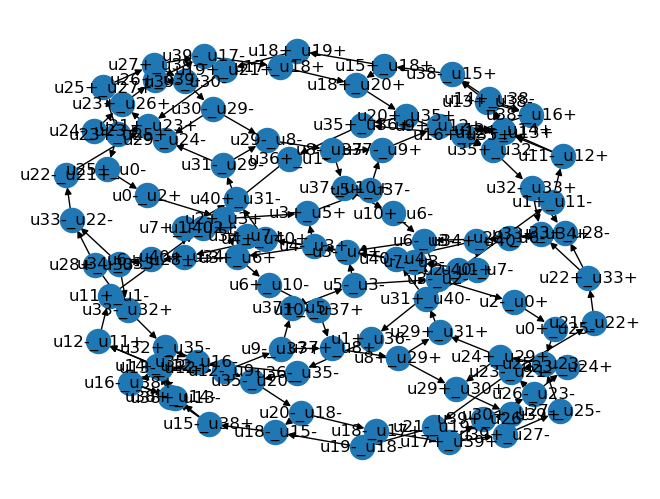

In [6]:
nx.draw_kamada_kawai(g, with_labels=True)

In [7]:
nodes = list(g.nodes)
V = int(len(nodes))
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)
qubo_matrix = np.zeros((T_max, V + 1, T_max, V + 1))

lambda_t = 16
lambda_g = 1
lambda_end = 8
lambda_w = 4

In [8]:
# Path
for t in range(T_max):
    for i in range(V):
        qubo_matrix[t, i, t, i] -= lambda_t
        qubo_matrix[t, V, t, i] += 2 * lambda_t
    qubo_matrix[t, V, t, V] -= lambda_t
    
    for i, j in product(range(V), range(V)):
        if not (i == j):
            qubo_matrix[t, i, t, j] += lambda_t
    
# Graph
for t in range(T_max - 1):
    qubo_matrix[t, :, t + 1, :] += lambda_g
    for edge in g.edges:
        qubo_matrix[t, nodes.index(edge[0]), t + 1, nodes.index(edge[1])] -= lambda_g
    for i in range(V + 1):
        qubo_matrix[t, i, t + 1, V] -= lambda_g
            
# Weights
for i in range(0, V, 2):
    for t in range(T_max):
        qubo_matrix[t, i, t, i] -= (2 * g.nodes[nodes[i]]["weight"] - 1) * lambda_w
        qubo_matrix[t, i + 1, t, i + 1] -= (2 * g.nodes[nodes[i]]["weight"] - 1) * lambda_w
    
    for t1, t2 in product(range(T_max), range(T_max)):
        qubo_matrix[t1, i, t2, i + 1] += 2 * lambda_w
        if not (t1 == t2):
            qubo_matrix[t1, i, t2, i] += lambda_w
            qubo_matrix[t1, i + 1, t2, i + 1] += lambda_w

qubo_matrix = qubo_matrix.reshape((T_max * (V+1)), (T_max * (V+1)))
qubo_matrix = 0.5 * (qubo_matrix + qubo_matrix.T)

In [9]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nodes[nz[1][i]] if nz[1][i] in range(V) else 'end') for i in range(nz[0].shape[0])]
        

In [10]:
def t_score(sample_arr):
    return sum(
        lambda_t * (1 - sum(sample_arr[t, i] for i in range(V)) - sample_arr[t, V]) ** 2 for t in range(T_max)
    )

def g_score(sample_arr):
    return lambda_g * sum(
        sample_arr[t, i] * sample_arr[t+1, j] * (1 if (nodes[i], nodes[j]) not in g.edges else 0)
        for t in range(T_max - 1) for i in range(V) for j in range(V)
    )   

def weight_score(sample_arr):
    return lambda_w * sum(
        (g.nodes[nodes[i]]["weight"] - sum(sample_arr[t, i] + sample_arr[t, i + 1] for t in range(T_max))) ** 2 for i in range(0, V, 2)
    )

In [11]:
bqm = BQM(qubo_matrix, 'BINARY')
bqm.offset = (T_max * lambda_t + lambda_w * sum(g.nodes[nodes[i]]["weight"] ** 2 for i in range(0, V, 2)))
bqm.offset

1468.0

In [12]:
print(bqm.num_variables)
print(bqm.num_interactions)
print(max(bqm.degrees().values()))
print(np.max(qubo_matrix))
print(np.min(qubo_matrix))

8103
1875441
469
20.0
-36.0


In [53]:
sim_annealer = SimulatedAnnealingSampler()

In [54]:
sampleset = sim_annealer.sample(bqm, num_reads=10)

KeyboardInterrupt: 

In [109]:
sample = sampleset.first.sample
energy = sampleset.first.energy
print(energy)
sample_list = np.array(list(sample.values()))
sample_array = sample_list.reshape((T_max, V + 1))
print(array_to_path(sample_array))

NameError: name 'sampleset' is not defined

In [ ]:
print(t_score(sample_array))
print(g_score(sample_array))
print(weight_score(sample_array))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(sample))

0
-4
0
0
2

4
2.0


In [ ]:
test_sample = np.zeros((T_max, V + 1))
test_sample[0, 0] = 1
test_sample[1, 2] = 1
test_sample[2, 4] = 1
test_sample[3, 6] = 1
test_sample[4, 8] = 1
test_sample[5, 10] = 1
test_sample_list = test_sample.reshape(T_max * (V + 1))

In [ ]:
print(t_score(test_sample))
print(g_score(test_sample))
print(weight_score(test_sample))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(test_sample_list))

0.0
-4.0
0.0
0.0
0.0

4
0.0


In [ ]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampler.min_time_limit(bqm)

4.09375

In [78]:
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Edge Tangle Testing k501", time_limit=120)

In [79]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_array = hybrid_sample_list.reshape((T_max, V + 1))
print(hybrid_energy)

24.0


In [76]:
# print(array_to_path(sample_array))
# print(array_to_path(test_sample))
print(array_to_path(hybrid_sample_array))
# u5-,u3-,u0-,u2+,u9+,u6-,u5+,u4-,u0-,u2+,u9+,u11+,u15+,u16+,u14-,u13-,u12+,u11-,u9-,u2-,u1+,u13-,u10-,u9-,u8+,u16-,u7-

[(0, 'u9-_u8+'), (1, 'u11+_u12-'), (2, 'u4+_u5-'), (3, 'u3-_u0-'), (4, 'u13+_u1-'), (5, 'u1-_u2+'), (6, 'u6+_u9-'), (7, 'u14-_u13-'), (8, 'u16+_u14-'), (9, 'u10-_u9-'), (10, 'u9-_u2-'), (11, 'u3-_u0-'), (12, 'u11-_u9-'), (13, 'u4-_u0-'), (14, 'u0-_u2+'), (15, 'u11-_u9-'), (16, 'u9-_u2-'), (17, 'u7+_u16+'), (18, 'u5-_u6+'), (19, 'u16+_u8-'), (20, 'u10+_u13+'), (21, 'u11+_u15+'), (22, 'u3+_u5+'), (23, 'u5+_u7+'), (24, 'u9-_u2-'), (25, 'u0-_u2+'), (26, 'u6-_u5+'), (27, 'u13-_u12+'), (28, 'u15+_u16+'), (29, 'end'), (30, 'end'), (31, 'end')]


In [77]:
print(t_score(hybrid_sample_array))
print(g_score(hybrid_sample_array))
print(weight_score(hybrid_sample_array))
print()
print(-lambda_g * (1 - T_max) - (T_max - total_weight))
print(bqm.energy(hybrid_sample_list))

0
-5
0
0
8

26
29.0


In [555]:
off_weights = [(g.nodes[nodes[i]]["weight"] - sum(hybrid_sample_array[t, i] + hybrid_sample_array[t, i + 1] for t in range(T_max))) for i in range(0, V, 2)]

In [556]:
off_weights
# 0+3+, 2+9+, 2-0+, 3+5+, 9+10+

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [13]:
# k501 path
# best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']

# k101 path
best_path_nodes = ["u21+","u23+","u25+","u27+","u39-","u30-","u29-","u24-","u23+","u25+","u0-","u2+","u3+","u6+","u10-","u37+","u5-","u3-","u2-","u1+","u11-","u12+","u14+","u38-","u16+","u35+","u32-","u33+","u34+","u40-","u7-","u3-","u2-","u1+","u36-","u35-","u20-","u18-","u17+","u39+","u26-","u23-","u21-","u19-","u18-","u15-","u38+","u13-","u12-","u9-","u37+","u8+","u29+","u31+","u40-","u4-","u3+","u6+","u28+","u33-","u22-", "u21+"]


best_path = [f'{best_path_nodes[i]}_{best_path_nodes[i+1]}' for i in range(len(best_path_nodes) - 1)]
best_path_sample = np.zeros((T_max, V+1))
for i in range(len(best_path)):
    best_path_sample[i, nodes.index(best_path[i])] = 1
best_path_sample[i+1:, -1] = 1
print(array_to_path(best_path_sample))


[(0, 'u21+_u23+'), (1, 'u23+_u25+'), (2, 'u25+_u27+'), (3, 'u27+_u39-'), (4, 'u39-_u30-'), (5, 'u30-_u29-'), (6, 'u29-_u24-'), (7, 'u24-_u23+'), (8, 'u23+_u25+'), (9, 'u25+_u0-'), (10, 'u0-_u2+'), (11, 'u2+_u3+'), (12, 'u3+_u6+'), (13, 'u6+_u10-'), (14, 'u10-_u37+'), (15, 'u37+_u5-'), (16, 'u5-_u3-'), (17, 'u3-_u2-'), (18, 'u2-_u1+'), (19, 'u1+_u11-'), (20, 'u11-_u12+'), (21, 'u12+_u14+'), (22, 'u14+_u38-'), (23, 'u38-_u16+'), (24, 'u16+_u35+'), (25, 'u35+_u32-'), (26, 'u32-_u33+'), (27, 'u33+_u34+'), (28, 'u34+_u40-'), (29, 'u40-_u7-'), (30, 'u7-_u3-'), (31, 'u3-_u2-'), (32, 'u2-_u1+'), (33, 'u1+_u36-'), (34, 'u36-_u35-'), (35, 'u35-_u20-'), (36, 'u20-_u18-'), (37, 'u18-_u17+'), (38, 'u17+_u39+'), (39, 'u39+_u26-'), (40, 'u26-_u23-'), (41, 'u23-_u21-'), (42, 'u21-_u19-'), (43, 'u19-_u18-'), (44, 'u18-_u15-'), (45, 'u15-_u38+'), (46, 'u38+_u13-'), (47, 'u13-_u12-'), (48, 'u12-_u9-'), (49, 'u9-_u37+'), (50, 'u37+_u8+'), (51, 'u8+_u29+'), (52, 'u29+_u31+'), (53, 'u31+_u40-'), (54, 'u40-_

In [32]:
print(t_score(best_path_sample))
print(g_score(best_path_sample))
print(weight_score(best_path_sample))
print()
best_path_sample_list = best_path_sample.reshape(T_max * (V + 1))
print(bqm.energy(best_path_sample_list))


0.0
0.0
0.0

0.0


In [15]:
best_path_sample_list @ qubo_matrix @ best_path_sample_list

-1468.0